# Phase 3: Baseline Ranking System and Failure@K Definition

Objective: Establish a simple, interpretable baseline ranking system and formally define Failure@K to provide a reference point for the analysis. 

## Phase 3 Goals:
1. Formally define Failure@K
2. Implement simple baseline ranker 
3. Evaluate baseline with P@K and NDCG@K for K={1,3,5,10}
4. Initial failure analysis
5. Output for later phases

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ndcg_score
import warnings
warnings.filterwarnings('ignore')

#Display settings
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',100)
pd.set_option('display.float_format','{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi']=100

#setup paths
PROJECT_ROOT=Path.cwd().parent
DATA_RAW=PROJECT_ROOT/'data'/'raw'
DATA_PROCESSED=PROJECT_ROOT/'data'/'processed'

#Creating outputs directory
PHASE3_OUTPUT=DATA_PROCESSED/'phase3_baseline'
PHASE3_OUTPUT.mkdir(parents=True,exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Phase 3 output directory: {PHASE3_OUTPUT}")

Project root: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding
Phase 3 output directory: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase3_baseline


# Loading Data

In [50]:
#Loading processed training data from Phase1
train_file=DATA_PROCESSED/'fold1_train_processed.csv'
print(f"Loading training data from: {train_file}")
train_df=pd.read_csv(train_file)

#Loading phase 2 feature statistics
feature_stats_file=DATA_PROCESSED/'fold1_feature_statistics.csv'
print(f"Loading feature statistics from: {feature_stats_file}")
feature_stats=pd.read_csv(feature_stats_file, index_col=0)

print(f"\nTraining data loaded: {train_df.shape}")
print(f"Feature statistics loaded: {feature_stats.shape}")

#Identifying feature columns
feature_cols = [col for col in train_df.columns if col.startswith('f') and col[1:].isdigit()]
feature_cols=sorted(feature_cols,key=lambda x: int(x[1:]))
num_features=len(feature_cols)

print(f"\nDataset overview:")
print(f"Features: {num_features}")
print(f"Documents: {len(train_df):,}")
print(f"Queries: {train_df['qid'].nunique():,}")
print(f"Labels: {sorted(train_df['label'].unique())}")

Loading training data from: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\fold1_train_processed.csv
Loading feature statistics from: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\fold1_feature_statistics.csv

Training data loaded: (42158, 49)
Feature statistics loaded: (46, 15)

Dataset overview:
Features: 46
Documents: 42,158
Queries: 1,017
Labels: [np.int64(0), np.int64(1), np.int64(2)]


## Loading Test Data

In [51]:
#We need to load and parse the test data
#Using the same parser from Phase 1

def parse_letor_file(filepath):
    data=[]
    with open(filepath, 'r') as f:
        for line_num, line in enumerate(f,1):
            line=line.strip()
            if not line:
                continue

            try:
                #Splitting comment (docid) from features
                parts=line.split("#")
                feature_part=parts[0].strip()

                #Extracting docid if present
                docid=None
                if len(parts)>1:
                    comment=parts[1].strip()
                    if 'docid' in comment:
                        docid=comment.split('=')[1].strip()

                #Parsing feature part
                tokens=feature_part.split()
                
                #Extracting label
                label=int(tokens[0])

                #Extracting qid
                qid_str=tokens[1]
                qid=int(qid_str.split(':')[1])

                #Extracting features
                features={}
                for token in tokens[2:]:
                    fid, value=token.split(':')
                    features[int(fid)]=float(value)

                data.append({
                    'label':label,
                    'qid':qid,
                    'features':features,
                    'docid':docid
                })

            except Exception as e:
                print(f"Error parsing line {line_num}: {e}")
                continue

    return data

#Loading test data
FOLD1_DIR=DATA_RAW/'MQ2007'/'Fold1'
TEST_FILE=FOLD1_DIR/'test.txt'

if not TEST_FILE.exists():
    print("Test file not found")

print(f"\nLoading test data from: {TEST_FILE}")
print(f"File exists: {TEST_FILE.exists()}")

if TEST_FILE.exists():
    test_data=parse_letor_file(str(TEST_FILE))

    #Converting to dataframe
    records=[]
    for item in test_data:
        record={
            'label':item['label'],
            'qid':item['qid'],
            'docid':item['docid']
        }
        for fid, value in item['features'].items():
            record[f'f{fid}']=value
        records.append(record)

    test_df=pd.DataFrame(records)
    print(f"Test data loaded: {test_df.shape}")
    print(f"Queries: {test_df['qid'].nunique():,}")
    print(f"Documents: {len(test_df):,}")

else:
    print(f"Test file not found. Please verify the path.")
    print(f"Expected location: {FOLD1_DIR}")


Loading test data from: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\raw\MQ2007\Fold1\test.txt
File exists: True
Test data loaded: (13652, 49)
Queries: 336
Documents: 13,652


## Phase 2 findings

In [52]:
print("="*60)
print("Phase 2 Findings Review")
print("="*60)

#Identifyiing zero variance features to exclude
zero_var_features=feature_stats[feature_stats['variance']==0].index.tolist()
print(f"\n1. Zero-variance features (to be excluded)")
print(f"Count:{len(zero_var_features)}")
if zero_var_features:
    print(f"Features: {zero_var_features}")
    print(f"Decision: These will be excluded from baseline")
else:
    print(f"No zero-variance features detected")

#Identifying most discriminative features from Phase 2
#We'll look at the features with high variance and good label separation
non_zero_features=[f for f in feature_cols if f not in zero_var_features]

print(f"\n2. Feature Screening for Baseline")
print(f"Total features: {num_features}")
print(f"Non-zero variance features: {len(non_zero_features)}")

#Computing feature discriminative power (simple mean difference between label 0 and 2)
if len(non_zero_features)>0:
    discriminative_power={}
    for feat in non_zero_features:
        label_0_mean=train_df[train_df['label']==0][feat].mean()
        label_2_mean=train_df[train_df['label']==2][feat].mean()
        discriminative_power[feat]=abs(label_2_mean-label_0_mean)

    #Sorting by discriminative power
    sorted_features=sorted(discriminative_power.items(), key=lambda x: x[1], reverse=True)
    print(f"\nTop 10 most discriminative features (by |mean(label=2)-mean(label=0)|):")
    for feat, power in sorted_features[:10]:
        print(f"{feat}:{power:.4f}")

    most_discriminative_feature=sorted_features[0][0]
    print(f"\nMost discriminative feature: {most_discriminative_feature}")

print(f"\n3. Variance Characteristics")
print(f"Mean feature variance: {feature_stats.loc[non_zero_features, 'variance'].mean():.4f}")
print(f"Mean feature sparsity: {feature_stats.loc[non_zero_features, 'pct_zeros'].mean():.2f}%")
print(f"\nPhase 2 conclusion: Strong within-query variance observed")
print(f"Phase 3 decision: Start with raw features (test normalization later)")

Phase 2 Findings Review

1. Zero-variance features (to be excluded)
Count:5
Features: ['f6', 'f7', 'f8', 'f9', 'f10']
Decision: These will be excluded from baseline

2. Feature Screening for Baseline
Total features: 46
Non-zero variance features: 41

Top 10 most discriminative features (by |mean(label=2)-mean(label=0)|):
f23:0.1803
f39:0.1782
f21:0.1570
f37:0.1526
f40:0.1350
f38:0.1255
f24:0.1252
f22:0.1240
f25:0.1024
f31:0.0971

Most discriminative feature: f23

3. Variance Characteristics
Mean feature variance: 0.0760
Mean feature sparsity: 36.83%

Phase 2 conclusion: Strong within-query variance observed
Phase 3 decision: Start with raw features (test normalization later)


We identified in phase 2 that there are 5 zero-variance features (f6-f10), which are now excluded from modeling because they provide no discriminative signal. 

The discriminative features that we listed are candidates for signal, not some guaranteed predictors.

# Task 1: Formally defining Failure@K

Definition:
- Failure@K = A query where NO relevant document appears in the top-K positions
- Relevance definition (primary): relevant if label >= 1
- Relevance definition (sensitivity): relevant if label = 2 (highly relevant only)

In [53]:
print("="*60)
print("Task 1: Formal definition of Failure@K")
print("="*60)

def is_failure_at_k(ranked_labels, k, relevance_threshold=1):
    """
    Determining if a query is a failure at K.
    Parameters:
    ranked_labels: array-like
        Labels in ranked order (predicted ranking)
    k: int
        Top-K cutoff
    relevance_threshold: int, default=1
        Threshold for relevance:
        - 1: relevant if label >= 1 (primary definition)
        - 2: relevant if label == 2 (sensitivity analysis)

    REturns:
    is_failure: bool
        True if no relevant document appears in top-K
    """
    if k<=0:
        raise ValueError(f"k must be >= 1, got k={k}")
    #if k is bigger than the list length, python just returns the full list

    if len(ranked_labels)==0:
        return True

    top_k_labels=ranked_labels[:k]

    if relevance_threshold==1:
        #Primary definition: relevant=label>=1
        has_relevant=any(label>=1 for label in top_k_labels)
    elif relevance_threshold==2:
        #Sensitivity definition:relevant: label==2
        has_relevant=any(label==2 for label in top_k_labels)
    else:
        raise ValueError(f"Invalid relevance_threshold: {relevance_threshold}")

    return not has_relevant

#Testing the function
print("\nFunction Definition:")
print("is_failure_at_k(ranked_labels, k, relevance_threshold=1)")
print("\nTest cases:")
test_rankings=[
    ([2,1,0,0],1,1,False),      #Relevant at position 1
    ([0,0,2,1],2,1,True),       #No relevant in top-2
    ([1,0,0,2],3,1,False),      #Relevant at position 1
    ([0,1,0,2],1,1,True),       #No relevant in top-1
    ([1,0,0,0],3,2,True),       #No highly relevant in top-3 (threshold=2)
    ([2,0,1,0],1,2,False),      #Highly relevant at position 1
]

for labels, k, threshold, expected in test_rankings:
    result=is_failure_at_k(labels,k,threshold)
    status="Yes" if result==expected else "No"
    print(f"{status} labels={labels}, K={k}, threshold={threshold} -> Failure={result} (expected {expected})")

print("\nFailure@K definition implemented and tested")

Task 1: Formal definition of Failure@K

Function Definition:
is_failure_at_k(ranked_labels, k, relevance_threshold=1)

Test cases:
Yes labels=[2, 1, 0, 0], K=1, threshold=1 -> Failure=False (expected False)
Yes labels=[0, 0, 2, 1], K=2, threshold=1 -> Failure=True (expected True)
Yes labels=[1, 0, 0, 2], K=3, threshold=1 -> Failure=False (expected False)
Yes labels=[0, 1, 0, 2], K=1, threshold=1 -> Failure=True (expected True)
Yes labels=[1, 0, 0, 0], K=3, threshold=2 -> Failure=True (expected True)
Yes labels=[2, 0, 1, 0], K=1, threshold=2 -> Failure=False (expected False)

Failure@K definition implemented and tested


- Primary relevance: "Did I get something helpful?"
- Sensitivity relevance: "Did I get the **best** thing?"
Using both lets us diagnose where and how our ranking model fails

Relevance labels:
0 -> not relevant
1 -> relevant
2 -> highly relevant

These labels are judgements of usefulness for a query.

Primary relevance: A document is considered relevant if label >= 1 (i.e., label 1 or 2)

Interpretation: This answers the question: "Did the user see anything useful in the top-K results?"
This is user-satisfaction-oriented  definition.
 For example:
 Rank          label          Interpretation
 1               1                useful
 2               0              not useful
 3               0              not useful

 Under primary relevance:
 - label 1 counts as relevant
 - top-3 contains a relevant doc
 - Failure@3 = False(success)

 Even if it's not the best result, the user found something helpful.

This aligns with recall-oriented evaluation

Sensitivity relevance: (label==2 only)
A document is considered relevant only if label==2

LAbel 1 does not count.

Interpretation: "Did the user see a high-quality/ ideal result in the top-K?"

This is more precision-focused and high-bar evaluation.

Example:
Same query:
Rank                     Label
1                          1
2                          0
3                          2

Under sensitivity relevance:
- label 1 does not count
- top-1: no label 2 -> Failure@1=True
- top-3: label 2 appears -> Failure@3=False

So, Failure@1 is higher
    Failure@3 improves

This is called "sensitivity" because:
- results are sensitive to ranking quality
- small ranking errors (putting 2 at rank 3 instead of 1) are exposed
- the evaluation becomes more demanding

Side-by-side comparison:
Rank                 Label
1                      1
2                      1
3                      0
4                      2

At K=2
 - Primary relevance (>=1):
     * labels[1,1] -> success
     * Failure@2 = False

 - Sensitivity relevance (=2):
     * no label 2 in top-2
     * Failure@2 = True

Same ranking, different interpretation

This tells us:
The model finds acceptable results early, but struggles to surface the best result early. 

# Task 2: Implementing Simple Baseline Ranker

### Baseline Choice: Pointwise Logistic Regression

Justification:
1. Simplicity: Linear model, easy to interpret
2. Transparency: Coefficients show feature importance
3. Established: Standard baseline
4. Multi-class support: Can handle labels {0,1,2}
5. No tuning needed: Default parameters for baseline

Implementation details:
- Using raw features (no normalization)
- Excluding zero-variance features
- Predicting probability scores, rank by score
- No hyperparameter tuning (default sklearn parameters)


In [54]:
print("="*60)
print("Task 2: Baseline Ranker Implementation")
print("="*80)

print("\nBaseline Choice: Pointwise Logistic Regression")
print("\nJustification")
print("1. Simple, interpretable linear model")
print("2. Transparent feature weights")
print("3. Standard LTR baseline")
print("4. Handles multi-class labels {0,1,2}")
print("5. No hyperparameter tuning needed")

#Preparing features (excluding zero-variance)
if len(zero_var_features)>0:
    active_features=[f for f in feature_cols if f not in zero_var_features]
    print(f"\nFeature preparation:")
    print(f" Total features: {len(feature_cols)}")
    print(f" Zero-variance excluded: {len(zero_var_features)}")
    print(f" Active features: {len(active_features)}")
else:
    active_features=feature_cols
    print(f"\nFeature preparation")
    print(f" All {len(feature_cols)} features active (no zero-variance features)")

#Extracting training data
X_train=train_df[active_features].values
y_train=train_df['label'].values

print(f"\nTraining data:")
print(f" X_train shape: {X_train.shape}")
print(f" y_train shape: {y_train.shape}")
print(f" Label distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")

#Training baseline model
print(f"\n Training Logistic Regression")
baseline_model=LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=36
)

baseline_model.fit(X_train, y_train)
print(f"Model trained successfully")

#Extracting test data
if 'test_df' in locals():
    X_test=test_df[active_features].values
    y_test=test_df['label'].values
    qids_test=test_df['qid'].values

    print(f"\nTest data:")
    print(f" X_test shape: {X_test.shape}")
    print(f" y_test shape: {y_test.shape}")
    print(f" Unique queries: {len(np.unique(qids_test))}")
else:
    print(f"\nTest data not loaded, cannot proceed with evaluation")

Task 2: Baseline Ranker Implementation

Baseline Choice: Pointwise Logistic Regression

Justification
1. Simple, interpretable linear model
2. Transparent feature weights
3. Standard LTR baseline
4. Handles multi-class labels {0,1,2}
5. No hyperparameter tuning needed

Feature preparation:
 Total features: 46
 Zero-variance excluded: 5
 Active features: 41

Training data:
 X_train shape: (42158, 41)
 y_train shape: (42158,)
 Label distribution: {np.int64(0): np.int64(31585), np.int64(1): np.int64(8388), np.int64(2): np.int64(2185)}

 Training Logistic Regression
Model trained successfully

Test data:
 X_test shape: (13652, 41)
 y_test shape: (13652,)
 Unique queries: 336


## Generating Predictions and Rankings

In [55]:
if 'test_df' in locals():
    print("Generating predictions for test set")

    #Predicting probability scores (using expected relevance score E[y] from class probabilities)
    #This gives us a continuous score for ranking
    y_pred_proba=baseline_model.predict_proba(X_test)

    #Using weighted score: sum of (class_value*probability)
    #THis gives higher scores to documents predicted to be more relevant
    classes=baseline_model.classes_
    scores=np.sum(y_pred_proba*classes.reshape(1,-1),axis=1)

    #adding scores to test dataframe
    test_df['score']=scores

    print(f"Scores computed")
    print(f"\nScore statistics:")
    print(f"Min: {scores.min():.4f}")
    print(f"Max: {scores.max():.4f}")
    print(f"Mean: {scores.mean():.4f}")
    print(f"Std: {scores.std():.4f}")

    #Creating rankings per query
    print(f"\nCreating per-query rankings")
    test_df['rank']=test_df.groupby('qid')['score'].rank(ascending=False,method='first').astype(int)

    print(f"Rankings created")
    print(f"\nSample query (qid={test_df['qid'].iloc[0]}):")
    sample_qid=test_df['qid'].iloc[0]
    sample_query=test_df[test_df['qid']==sample_qid][['qid','label','score','rank']].sort_values('rank')
    display(sample_query.head(10))

else:
    print("Test data not available")

Generating predictions for test set
Scores computed

Score statistics:
Min: 0.0168
Max: 1.1613
Mean: 0.3104
Std: 0.1693

Creating per-query rankings
Rankings created

Sample query (qid=7968):


,qid,label,score,rank
17,7968,2,0.6277,1
25,7968,1,0.5291,2
6,7968,1,0.4723,3
23,7968,1,0.4663,4
12,7968,0,0.4160,5
4,7968,0,0.4021,6
31,7968,1,0.3945,7
14,7968,1,0.3919,8
15,7968,1,0.3879,9
1,7968,1,0.3808,10


# Task 3: Evaluating Baseline with P@K and NDCG@K

Compute metrics for K belonging to {1,3,5,10} at both query-level and aggregate

In [56]:
def precision_at_k(ranked_labels, k, relevance_threshold=1):
    """
    Computing Precision@K

    Parameters:
    ranked labels: array-like
        Labels in ranked order
    k:int
        Top-K cutoff
    relevance_threshold: int
        Threshold for relevance (1 or 2)

    REturns:
    precision: float
        Precision@K value
    """
    if k<=0:
        raise ValueError(f"k must be >= 1, got k={k}")

    if len(ranked_labels)==0:
        return 0.0

    den=min(k,len(ranked_labels))

    top_k=ranked_labels[:den]

    if relevance_threshold==1:
        relevant_count=sum(label>=1 for label in top_k)
    elif relevance_threshold==2:
        relevant_count=sum(label==2 for label in top_k)
    else:
        raise ValueError(f"Relevance_threshold must be 1 or 2, got {relevance_threshold}")
    
    return relevant_count/den

def ndcg_at_k(ranked_labels,k):
    """
    Computing NDCG@K

    Parameters:
    ranked_labels:array_like
        Labels in ranked order
    k:int
        Top-K cutoff

    REturns:
    ndcg:float
        NDCG@K value
    """

    if len(ranked_labels) ==0:
        return 0.0

    #Computing DCG@K
    #DCG => Discounted Cumulative Gain
    dcg=0.0
    for i, label in enumerate(ranked_labels[:k]):   #enumerate gives i=0,1,2,...
        dcg+=(2**label - 1)/np.log2(i+2)    #i+2 because rank starts at 1
        #gain=2^label-1 Example: label 0 => gain=0, label 1 => gain=1, label2 => gain=3
        #discount=np.log2(i+2) i.e. log2(rank+1) because NDCG gives full credit to rank 1 and reduces credit as rank increases
        #And as rank starts from 1 but i starts from 0, we have to do i+2 to get to second rank

        """
        Discount values:
        Rank            log2(rank+1)        Discount
        1               log2(2)=1           no discounr
        2               log2(3)=1.585       less credit
        3               log2(4)=2           half credit
        4               log2(5)=2.32        even less
        5               log2(6)=2.58        even less
        """

    #Computing IDCG@K (ideal DCG)
    #Idcg just sorts the labels in descending order to get the max possible dcg
    ideal_labels=sorted(ranked_labels, reverse=True)[:k]
    idcg=0.0
    for i, label in enumerate(ideal_labels):
        idcg+=(2**label-1)/np.log2(i+2)

    if idcg==0:
        return 0.0

    return dcg/idcg

print("="*60)
print("Task 3: Baseline Evaluation")
print("="*60)

#Testing metric functions
print("\nTesting metric functions:")
test_ranking=[2,1,0,0,1]
print(f"Test ranking: {test_ranking}")
print(f"P@3: {precision_at_k(test_ranking,3,1):.4f}")
print(f"NDCG@3: {ndcg_at_k(test_ranking,3):.4f}")
print(f"P@5: {precision_at_k(test_ranking, 5,1):.4f}")
print(f"NDCG@5: {ndcg_at_k(test_ranking,5):.4f}")
print(f"Metric functions implemented")

Task 3: Baseline Evaluation

Testing metric functions:
Test ranking: [2, 1, 0, 0, 1]
P@3: 0.6667
NDCG@3: 0.8790
P@5: 0.6000
NDCG@5: 0.9726
Metric functions implemented


Normalized Discounted Cumulative Gain (NDCG) doesn’t need a 'threshold' because it uses the graded labels (0,1,2). It rewards putting label 2 higher than label 1, etc.

EXAMPLE:
Primary relevance: label >= 1 -> relevant
Sensitivity relevance: label==2 -> relevant

Metrics like Precision@K and Failure@K need this, because they are binary: relevant or not relevant.

Why NDCG is different:
NDCG does not convert labels into relevant/ not relevant. Instead, it uses the actual label values: 0,1,2. So, NDCG knows: label 2 is better than label 1 and label 1 is better than label 0. This is called **graded relevance**. 

Simple example:
Doc A: label 2 (highly relevant)
Doc B: label 1 (relevant)
Doc C: label 0 (not relevant)

Now comparing two rankings.

Ranking 1 (better ranking):
Rank 1: label 2
Rank 2: label 1
Rank 3: label 0

Ranking 2 (worse ranking):
Rank 1: label 1
Rank 2: label 2
Rank 3: label 0

What Precision@1 would say:
- Ranking 1: P@1=1 (relevant)
- Ranking 2: P@1=1 (also relevant)
So, no differnce found

What NDCG says
NDCG rewards Ranking 1 more because:
the better document (label 2) is placed higher. 

Therefore, NDCG doesn't need a relevance threshold.

In [57]:
def verify_ndcg_implementation_gain_matched():
    ranked_labels=np.array([2, 1, 0, 0, 1], dtype=float)

    #Dummy scores preserve this exact order (no ties)
    dummy_scores=np.arange(len(ranked_labels), 0, -1).astype(float)

    #Transforming labels into gains to match our custom DCG gain: 2^label - 1
    y_true_gains=(2 ** ranked_labels) - 1

    for k in [1, 3, 5]:
        custom=ndcg_at_k(ranked_labels.tolist(), k)

        sk=ndcg_score(
            y_true=y_true_gains.reshape(1, -1),
            y_score=dummy_scores.reshape(1, -1),
            k=k
        )

        print(f"K={k}: custom={custom:.6f}, sklearn={sk:.6f}, diff={abs(custom-sk):.6e}")

verify_ndcg_implementation_gain_matched()


K=1: custom=1.000000, sklearn=1.000000, diff=0.000000e+00
K=3: custom=0.878962, sklearn=0.878962, diff=1.110223e-16
K=5: custom=0.972610, sklearn=0.972610, diff=0.000000e+00


## Computing Query-level metrics

In [58]:
if 'test_df' in locals():
    print("\n Computing query-level metrics")

    K_VALUES=[1,3,5,10]
    RELEVANCE_THRESHOLDS={
        'primary':1 ,        #relevant if label>=1
        'sensitivity':2     #relevant if label==2
    }

    #Storing results per query
    query_results=[]

    for qid in test_df['qid'].unique():
        query_data=test_df[test_df['qid']==qid].sort_values('rank')
        ranked_labels=query_data['label'].values #becomes an array like [2,1,1,0,0,1,...]

        result={
            'qid':qid,
            'num_docs':len(ranked_labels),
            'num_relevant_1':sum(ranked_labels>=1),
            'num_relevant_2':sum(ranked_labels==2),
        }

        #Computing metrics for each k and relevance definition
        for k in K_VALUES:
            #Primary relevance (label >=1)
            result[f'P@{k}_primary']=precision_at_k(ranked_labels,k,1)
            result[f'NDCG@{k}']=ndcg_at_k(ranked_labels,k)
            result[f'Failure@{k}_primary']=is_failure_at_k(ranked_labels,k,1)

            #Sensitivity relevance (label==2)
            result[f'P@{k}_sensitivity']=precision_at_k(ranked_labels,k,2)
            result[f'Failure@{k}_sensitivity']=is_failure_at_k(ranked_labels,k,2)

        query_results.append(result)

    #converting to DataFrame
    query_metrics_df=pd.DataFrame(query_results)

    print(f"Query-level metrics computed for {len(query_metrics_df)} queries")
    print(f"\nFirst 5 queries")
    display(query_metrics_df.head())

    #saving query-level results
    query_metrics_file=PHASE3_OUTPUT/'baseline_query_metrics.csv'
    query_metrics_df.to_csv(query_metrics_file, index=False)
    print(f"\n Saved query-level metrics to: {query_metrics_file}")
else:
    print("Test data not available")


 Computing query-level metrics
Query-level metrics computed for 336 queries

First 5 queries


,qid,num_docs,num_relevant_1,num_relevant_2,P@1_primary,NDCG@1,Failure@1_primary,P@1_sensitivity,Failure@1_sensitivity,P@3_primary,NDCG@3,Failure@3_primary,P@3_sensitivity,Failure@3_sensitivity,P@5_primary,NDCG@5,Failure@5_primary,P@5_sensitivity,Failure@5_sensitivity,P@10_primary,NDCG@10,Failure@10_primary,P@10_sensitivity,Failure@10_sensitivity
0,7968,40,20,1,1.0000,1.0000,False,1.0000,False,1.0000,1.0000,False,0.3333,False,0.8000,0.9218,False,0.2000,False,0.8000,0.8864,False,0.1000,False
1,7979,40,5,4,1.0000,1.0000,False,1.0000,False,1.0000,1.0000,False,1.0000,False,0.8000,0.9521,False,0.8000,False,0.4000,0.9521,False,0.4000,False
2,7993,40,5,0,1.0000,1.0000,False,0.0000,True,0.6667,0.7654,False,0.0000,True,0.4000,0.5531,False,0.0000,True,0.2000,0.5531,False,0.0000,True
3,7995,50,4,0,1.0000,1.0000,False,0.0000,True,0.3333,0.4693,False,0.0000,True,0.2000,0.3904,False,0.0000,True,0.2000,0.5135,False,0.0000,True
4,8002,40,20,0,0.0000,0.0000,True,0.0000,True,0.3333,0.2961,False,0.0000,True,0.2000,0.2140,False,0.0000,True,0.3000,0.2809,False,0.0000,True



 Saved query-level metrics to: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase3_baseline\baseline_query_metrics.csv


## Aggregating metrics

In [59]:
if 'query_metrics_df' in locals():
    print("="*60)
    print("Aggregate metrics (Primary relevance: label >=1)")
    print("="*60)

    aggregate_results={'K':[], 'P@K':[],'NDCG@K':[],'Failure Rate':[]}

    for k in K_VALUES:
        p_at_k=query_metrics_df[f'P@{k}_primary'].mean()
        ndcg_at_k_val=query_metrics_df[f'NDCG@{k}'].mean()
        failure_rate=query_metrics_df[f'Failure@{k}_primary'].mean()

        aggregate_results['K'].append(k)
        aggregate_results['P@K'].append(p_at_k)
        aggregate_results['NDCG@K'].append(ndcg_at_k_val)
        aggregate_results['Failure Rate'].append(failure_rate)

        print(f"\nK={k}:")
        print(f"P@{k}: {p_at_k:.4f}")
        print(f"NDCG@{k}: {ndcg_at_k_val:.4f}")
        print(f"Failure@{k} rate: {failure_rate:.4f} ({failure_rate*100:.2f}%)")
        print(f"Queries failing: {query_metrics_df[f'Failure@{k}_primary'].sum()}/{len(query_metrics_df)}")

    aggregate_df=pd.DataFrame(aggregate_results)

    print("\n"+"="*60)
    print("Aggregate metrics (Sensitivity: label==2)")
    print("="*60)

    sensitivity_aggregate_results = {'K': [], 'P@K': [], 'Failure Rate': []}

    for k in K_VALUES:
        p_at_k=query_metrics_df[f'P@{k}_sensitivity'].mean()
        failure_rate=query_metrics_df[f'Failure@{k}_sensitivity'].mean()

        sensitivity_aggregate_results['K'].append(k)
        sensitivity_aggregate_results['P@K'].append(p_at_k)
        sensitivity_aggregate_results['Failure Rate'].append(failure_rate)


        print(f"\nK={k}:")
        print(f"P@{k}: {p_at_k:.4f}")

        print(f"Failure@{k} rate: {failure_rate:.4f} ({failure_rate*100:.2f}%)")
        print(f"Queries failing: {query_metrics_df[f'Failure@{k}_sensitivity'].sum()}/{len(query_metrics_df)}")

    sensitivity_aggregate_df = pd.DataFrame(sensitivity_aggregate_results)

    #Saving aggregate metrics
    aggregate_file=PHASE3_OUTPUT/'baseline_aggregate_metrics.csv'
    aggregate_df.to_csv(aggregate_file, index=False)
    print(f"\nSaved aggregate metrics to: {aggregate_file}")

    sensitivity_aggregate_file = PHASE3_OUTPUT / 'baseline_aggregate_metrics_sensitivity.csv'
    sensitivity_aggregate_df.to_csv(sensitivity_aggregate_file, index=False)
    print(f"\nSaved sensitivity aggregate metrics to: {sensitivity_aggregate_file}")

else:
    print("Metrics not computed")

Aggregate metrics (Primary relevance: label >=1)

K=1:
P@1: 0.4643
NDCG@1: 0.4127
Failure@1 rate: 0.5357 (53.57%)
Queries failing: 180/336

K=3:
P@3: 0.4335
NDCG@3: 0.4159
Failure@3 rate: 0.3512 (35.12%)
Queries failing: 118/336

K=5:
P@5: 0.4208
NDCG@5: 0.4284
Failure@5 rate: 0.2679 (26.79%)
Queries failing: 90/336

K=10:
P@10: 0.3908
NDCG@10: 0.4564
Failure@10 rate: 0.2083 (20.83%)
Queries failing: 70/336

Aggregate metrics (Sensitivity: label==2)

K=1:
P@1: 0.1518
Failure@1 rate: 0.8482 (84.82%)
Queries failing: 285/336

K=3:
P@3: 0.1389
Failure@3 rate: 0.7381 (73.81%)
Queries failing: 248/336

K=5:
P@5: 0.1280
Failure@5 rate: 0.6905 (69.05%)
Queries failing: 232/336

K=10:
P@10: 0.1080
Failure@10 rate: 0.6190 (61.90%)
Queries failing: 208/336

Saved aggregate metrics to: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase3_baseline\baseline_aggregate_metrics.csv

Saved sensitivity aggregate metrics to: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding

## Visualizing Metrics

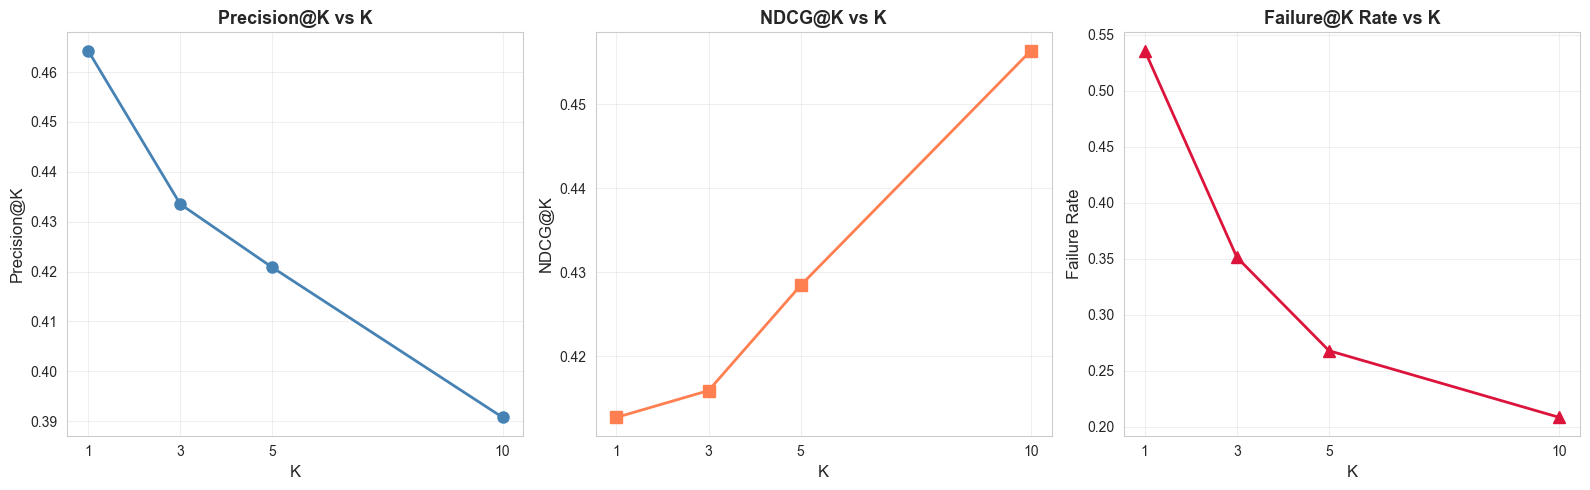

Saved metrics visualization to: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase3_baseline\baseline_metrics_plot.png


In [60]:
if 'aggregate_df' in locals():
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    #Plot 1: P@K vs K
    axes[0].plot(aggregate_df['K'], aggregate_df['P@K'], marker='o', linewidth=2, markersize=8, color='steelblue')
    axes[0].set_xlabel('K', fontsize=12)
    axes[0].set_ylabel('Precision@K', fontsize=12)
    axes[0].set_title('Precision@K vs K', fontweight='bold', fontsize=13)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(K_VALUES)
    
    #Plot 2: NDCG@K vs K
    axes[1].plot(aggregate_df['K'], aggregate_df['NDCG@K'], marker='s', linewidth=2, markersize=8, color='coral')
    axes[1].set_xlabel('K', fontsize=12)
    axes[1].set_ylabel('NDCG@K', fontsize=12)
    axes[1].set_title('NDCG@K vs K', fontweight='bold', fontsize=13)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(K_VALUES)
    
    #Plot 3: Failure Rate vs K
    axes[2].plot(aggregate_df['K'], aggregate_df['Failure Rate'], marker='^', linewidth=2, markersize=8, color='crimson')
    axes[2].set_xlabel('K', fontsize=12)
    axes[2].set_ylabel('Failure Rate', fontsize=12)
    axes[2].set_title('Failure@K Rate vs K', fontweight='bold', fontsize=13)
    axes[2].grid(True, alpha=0.3)
    axes[2].set_xticks(K_VALUES)
    
    plt.tight_layout()
    plt.savefig(PHASE3_OUTPUT / 'baseline_metrics_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Saved metrics visualization to: {PHASE3_OUTPUT / 'baseline_metrics_plot.png'}")
else:
    print("Aggregate metrics not available")

Precision@K decreases with K because more documents means more chances of labels being 0

Second plot shows that the baseline often ranks relevant documents below rank1, but still withjn the top-10.

Third plot shows that more than half of queries fail at rank 1 and by rank 10, only 21% still fail

# Task 4: Initial Failure Analysis
Comparing characteristics of successful vs failed queries

In [61]:
if 'query_metrics_df' in locals():
    print("="*60)
    print("Task 4: Initial Failure Analysis")
    print("="*60)

    #analyzing for K=5 (middle)
    K_ANALYSIS=5

    print(f"\nAnalyzing failures at K={K_ANALYSIS} (primary relevance: label>=1)")

    #Separating successful and failed queries
    failed_queries=query_metrics_df[query_metrics_df[f'Failure@{K_ANALYSIS}_primary']==True]
    successful_queries=query_metrics_df[query_metrics_df[f'Failure@{K_ANALYSIS}_primary']==False]

    print(f"\n1. Query Counts")
    print(f"Total queries: {len(query_metrics_df)}")
    print(f"Successful queries: {len(successful_queries)} ({100*len(successful_queries)/len(query_metrics_df):.2f}%)")
    print(f"Failed queries: {len(failed_queries)} ({100*len(failed_queries)/len(query_metrics_df):.2f}%)")

    if len(failed_queries) >0 and len(successful_queries) >0:
        print(f"\n2. Number of Documents per Query")
        print(f"Successful Queries:")
        print(f" Mean: {successful_queries['num_docs'].mean():.2f}")
        print(f" Median: {successful_queries['num_docs'].median():.2f}")
        print(f" Std: {successful_queries['num_docs'].std():.2f}")
        print(f" Min: {successful_queries['num_docs'].min()}")
        print(f" Max: {successful_queries['num_docs'].max()}")

        print(f"\nFailed Queries:")
        print(f" Mean: {failed_queries['num_docs'].mean():.2f}")
        print(f" Median: {failed_queries['num_docs'].median():.2f}")
        print(f" Std: {failed_queries['num_docs'].std():.2f}")
        print(f" Min: {failed_queries['num_docs'].min()}")
        print(f" Max: {failed_queries['num_docs'].max()}")

        print(f"\n3. Number of RElevant Documents Per Query (label >=1)")
        print(f"Successful queries:")
        print(f" Mean: {successful_queries['num_relevant_1'].mean():.2f}")
        print(f" Median: {successful_queries['num_relevant_1'].median():.2f}") 
        print(f" Std: {successful_queries['num_relevant_1'].std():.2f}")

        print(f"\nFailed queries:")
        print(f" Mean: {failed_queries['num_relevant_1'].mean():.2f}")
        print(f" Median: {failed_queries['num_relevant_1'].median():.2f}")
        print(f" Std: {failed_queries['num_relevant_1'].std():.2f}")

        print(f"\n4. Number of HIghly Relevant Documents Per Query (label==2)")
        print(f"Successful queries:")
        print(f" Mean: {successful_queries['num_relevant_2'].mean():.2f}")
        print(f" Median: {successful_queries['num_relevant_2'].median():.2f}")

        print(f"\nFailed queries:")
        print(f" Mean: {failed_queries['num_relevant_2'].mean():.2f}")
        print(f" Median: {failed_queries['num_relevant_2'].median():.2f}")

        #Saving failure analysis
        failure_comparison=pd.DataFrame({
            'Metric':['Num Queries','Mean Docs','Mean Relevant (>=1)','Mean Highly Relevant (=2)'],
            'Successful':[
                len(successful_queries),
                successful_queries['num_docs'].mean(),
                successful_queries['num_relevant_1'].mean(),
                successful_queries['num_relevant_2'].mean()
            ],
            'Failed':[
                len(failed_queries),
                failed_queries['num_docs'].mean(),
                failed_queries['num_relevant_1'].mean(),
                failed_queries['num_relevant_2'].mean(),
            ]
        })

        failure_analysis_file=PHASE3_OUTPUT/f'failure_analysis_K{K_ANALYSIS}.csv'
        failure_comparison.to_csv(failure_analysis_file,index=False)
        print(f"\nSaved failure analysis to: {failure_analysis_file}")

    else:
        print("\n All queries either succeeded or failed - no comparison possible")

else:
    print("Query metrics not available")

Task 4: Initial Failure Analysis

Analyzing failures at K=5 (primary relevance: label>=1)

1. Query Counts
Total queries: 336
Successful queries: 246 (73.21%)
Failed queries: 90 (26.79%)

2. Number of Documents per Query
Successful Queries:
 Mean: 40.41
 Median: 40.00
 Std: 2.95
 Min: 40
 Max: 80

Failed Queries:
 Mean: 41.24
 Median: 40.00
 Std: 5.03
 Min: 40
 Max: 79

3. Number of RElevant Documents Per Query (label >=1)
Successful queries:
 Mean: 14.70
 Median: 13.00
 Std: 9.92

Failed queries:
 Mean: 1.72
 Median: 0.00
 Std: 3.05

4. Number of HIghly Relevant Documents Per Query (label==2)
Successful queries:
 Mean: 3.50
 Median: 1.00

Failed queries:
 Mean: 0.60
 Median: 0.00

Saved failure analysis to: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase3_baseline\failure_analysis_K5.csv


Failed queries are heavily concentrated among queries with extremely low (often zero) numbers of relevant documents, suggesting a long-tail/sparse-relevance regime rather than purely ranking error.

## Visualizing Failure Analysis

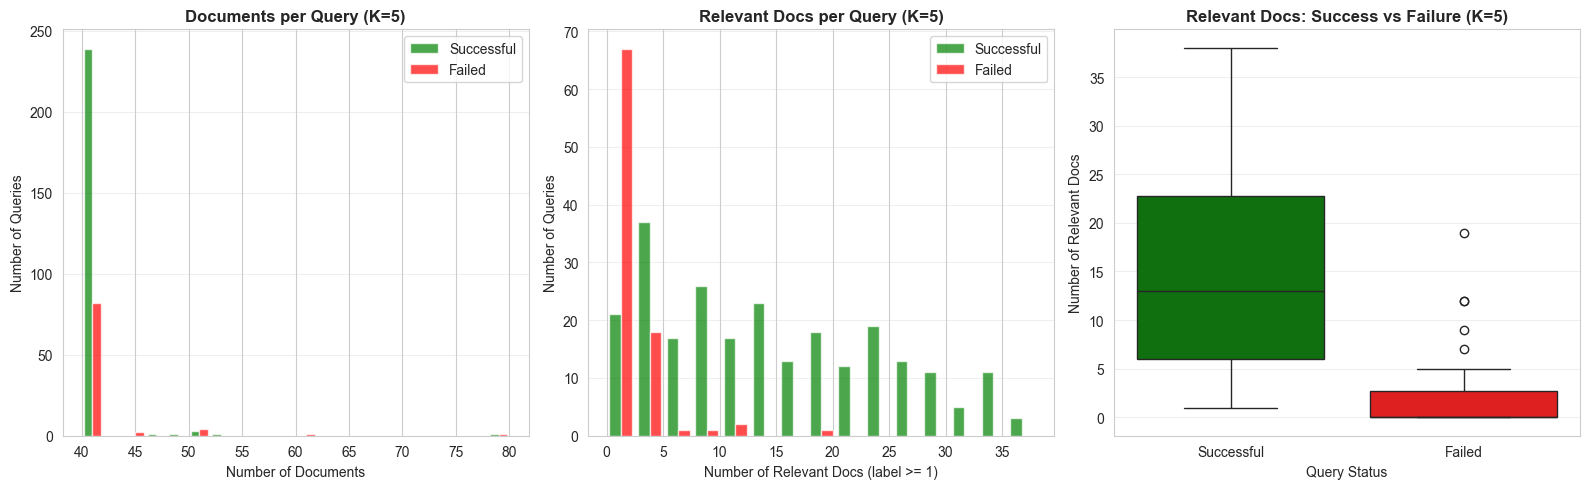

Saved failure analysis visualization to: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase3_baseline\failure_analysis_plot.png


In [62]:
if 'failed_queries' in locals() and len(failed_queries) > 0 and len(successful_queries) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    #Plot 1: Documents per query
    axes[0].hist([successful_queries['num_docs'], failed_queries['num_docs']], 
                 bins=20, label=['Successful', 'Failed'], alpha=0.7, color=['green', 'red'])
    axes[0].set_xlabel('Number of Documents')
    axes[0].set_ylabel('Number of Queries')
    axes[0].set_title(f'Documents per Query (K={K_ANALYSIS})', fontweight='bold')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    #Plot 2: Relevant documents per query
    axes[1].hist([successful_queries['num_relevant_1'], failed_queries['num_relevant_1']], 
                 bins=15, label=['Successful', 'Failed'], alpha=0.7, color=['green', 'red'])
    axes[1].set_xlabel('Number of Relevant Docs (label >= 1)')
    axes[1].set_ylabel('Number of Queries')
    axes[1].set_title(f'Relevant Docs per Query (K={K_ANALYSIS})', fontweight='bold')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    
    #Plot 3: Box plot comparison
    comparison_data = pd.DataFrame({
        'Status': ['Successful'] * len(successful_queries) + ['Failed'] * len(failed_queries),
        'Num_Relevant': list(successful_queries['num_relevant_1']) + list(failed_queries['num_relevant_1'])
    })
    sns.boxplot(data=comparison_data, x='Status', y='Num_Relevant', ax=axes[2], palette=['green', 'red'])
    axes[2].set_xlabel('Query Status')
    axes[2].set_ylabel('Number of Relevant Docs')
    axes[2].set_title(f'Relevant Docs: Success vs Failure (K={K_ANALYSIS})', fontweight='bold')
    axes[2].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(PHASE3_OUTPUT / 'failure_analysis_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Saved failure analysis visualization to: {PHASE3_OUTPUT / 'failure_analysis_plot.png'}")
else:
    print("Insufficient data for visualization")

Plot 1 shows thatboth green and red have a big spike around 40 docs. The distributions overlap heavily. This means that the query size is not the driver of failure. Failed queries are not failing because they have fewer candidates to choose from. 

Second plot shows that red (failed) is heavily concentrated near 0 relevant docs. Green spreads across a wide range (many queries have 5-35 relevant documents). Failures are dominated by queries that have very few (often zero) relevant documents in the entire pool.

Third plot shows successful has median around 13 and is wide spread (some queries have many relevant docs). Meanwhile, failed has median at 0, very tight box near 0 and few outliers (some failed queries still had a moderate number of relevant docs but weren't surfaced in top 5). This means **outliers matter** in this case. The red outliers are the "true model failures". 

There is a small subset of failures that occurs even when relevant documents exist. These cases require deeper diagnosis.

## Looking at avaidable and unavoidable failures

In [63]:
#Splitting failed queries into unavoidable vs avoidable
unavoidable_failures=failed_queries[failed_queries['num_relevant_1']==0]
avoidable_failures=failed_queries[failed_queries['num_relevant_1']>0]

print("\nFailure Breakdown at K=5 (Primary relevance)")
print(f"Total failed queries: {len(failed_queries)}")
print(f"Unavoidable failures (no relevant docs exist): {len(unavoidable_failures)} "
      f"({100*len(unavoidable_failures)/len(failed_queries):.2f}%)")
print(f"Avoidable failures (relevant docs exist but not retrieved): {len(avoidable_failures)} "
      f"({100*len(avoidable_failures)/len(failed_queries):.2f}%)")



Failure Breakdown at K=5 (Primary relevance)
Total failed queries: 90
Unavoidable failures (no relevant docs exist): 46 (51.11%)
Avoidable failures (relevant docs exist but not retrieved): 44 (48.89%)


About half of our Failure@5 cases are not fixable by any ranking model, because the query literally contains zero relevant documents under our definition of label >= 1.

The other 49% are real model failures: ranking docs exist but the baseline didn't bring any into the top 5.

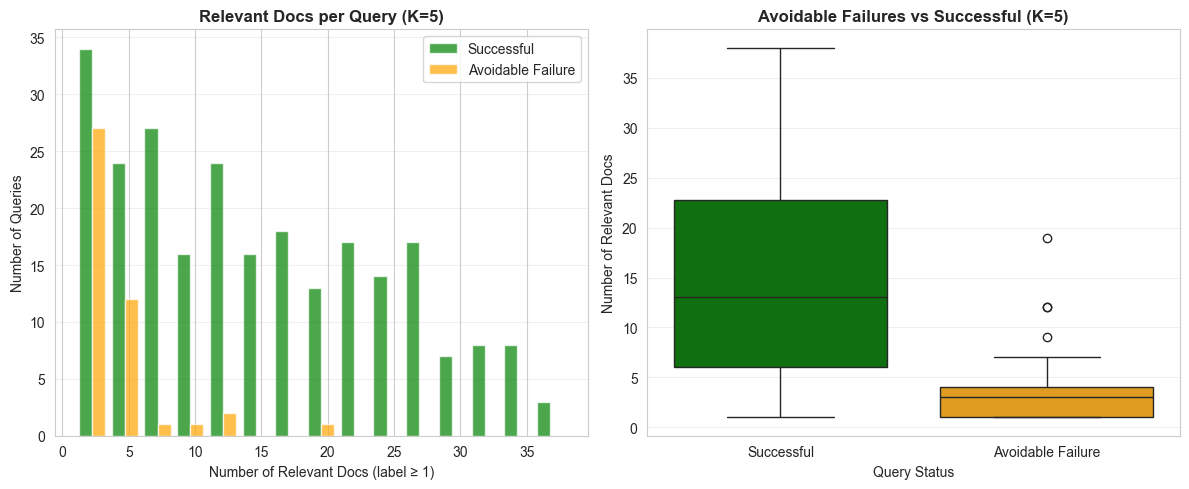

Saved avoidable failure visualization to: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase3_baseline\avoidable_failure_analysis_K5.png


In [64]:
if len(avoidable_failures) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot 1: Histogram of relevant docs (label >=1)
    axes[0].hist(
        [successful_queries['num_relevant_1'], avoidable_failures['num_relevant_1']],
        bins=15,
        label=['Successful', 'Avoidable Failure'],
        alpha=0.7,
        color=['green', 'orange']
    )
    axes[0].set_xlabel('Number of Relevant Docs (label ≥ 1)')
    axes[0].set_ylabel('Number of Queries')
    axes[0].set_title('Relevant Docs per Query (K=5)', fontweight='bold')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # Plot 2: Boxplot comparison
    comparison_df = pd.DataFrame({
        'Status': (
            ['Successful'] * len(successful_queries) +
            ['Avoidable Failure'] * len(avoidable_failures)
        ),
        'Num_Relevant': (
            list(successful_queries['num_relevant_1']) +
            list(avoidable_failures['num_relevant_1'])
        )
    })

    sns.boxplot(
        data=comparison_df,
        x='Status',
        y='Num_Relevant',
        ax=axes[1],
        palette={'Successful': 'green', 'Avoidable Failure': 'orange'}
    )
    axes[1].set_xlabel('Query Status')
    axes[1].set_ylabel('Number of Relevant Docs')
    axes[1].set_title('Avoidable Failures vs Successful (K=5)', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(PHASE3_OUTPUT / 'avoidable_failure_analysis_K5.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Saved avoidable failure visualization to: "
          f"{PHASE3_OUTPUT / 'avoidable_failure_analysis_K5.png'}")
else:
    print("No avoidable failures to visualize.")


We can see here, even among "avoidable failures", many are low-signal queries (few relevant docs exist), meaning ranking is harder and mistakes are easier.

The second plot shows a few outliers (queries that had more relevant docs but still failed). These outliers are the best candidates for further analysis.

## Checking conditional failure@k (primary relevance)

In [65]:
print("="*65)
print("Conditional Failure@K (Primary relevance | num_relevant_1 > 0)")
print("="*65)

conditional_results={
    'K':[],
    'Feasible Queries':[],
    'Avoidable Failures':[],
    'Conditional Failure Rate':[]
}

#Feasible queries: at least one relevant document exists
feasible_queries=query_metrics_df[query_metrics_df['num_relevant_1'] > 0]

for k in K_VALUES:
    avoidable_failures_k=feasible_queries[
        feasible_queries[f'Failure@{k}_primary']==True
    ]

    conditional_rate=(
        len(avoidable_failures_k)/len(feasible_queries)
        if len(feasible_queries)>0 else 0.0
    )

    conditional_results['K'].append(k)
    conditional_results['Feasible Queries'].append(len(feasible_queries))
    conditional_results['Avoidable Failures'].append(len(avoidable_failures_k))
    conditional_results['Conditional Failure Rate'].append(conditional_rate)

    print(f"\nK={k}:")
    print(f" Feasible queries: {len(feasible_queries)}")
    print(f" Avoidable failures: {len(avoidable_failures_k)}")
    print(f" Conditional Failure@{k}: {conditional_rate:.4f} ({conditional_rate*100:.2f}%)")

#Converting to DataFrame
conditional_failure_df=pd.DataFrame(conditional_results)

#Saving results
conditional_failure_file=PHASE3_OUTPUT / 'baseline_conditional_failure_metrics.csv'
conditional_failure_df.to_csv(conditional_failure_file, index=False)

print(f"\nSaved conditional failure metrics to: {conditional_failure_file}")


Conditional Failure@K (Primary relevance | num_relevant_1 > 0)

K=1:
 Feasible queries: 290
 Avoidable failures: 134
 Conditional Failure@1: 0.4621 (46.21%)

K=3:
 Feasible queries: 290
 Avoidable failures: 72
 Conditional Failure@3: 0.2483 (24.83%)

K=5:
 Feasible queries: 290
 Avoidable failures: 44
 Conditional Failure@5: 0.1517 (15.17%)

K=10:
 Feasible queries: 290
 Avoidable failures: 24
 Conditional Failure@10: 0.0828 (8.28%)

Saved conditional failure metrics to: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase3_baseline\baseline_conditional_failure_metrics.csv


K=1: Even when there is at least one relevant document in the query, the model still fails to put any relevant doc at rank 1 in almost half the feasible queries.

k=3: 24.83%
Once we allow top3, failures drop sharply. This means relevant docs often appear in ranks 2-3 even when rank 1 is wrong.

k=5: 15.17%
When at least one relevant exists, baseline still missses top-5 in 15% of queries.

k=10: 8.28%
By top 10, the baseline almost always finds at least one relevant doc in feasible queries. So, most of the remaining failures at k=10 are probably either extremely low-signal queries (only 1 reelevant doc +poor separation) or tie/flat-score behavior.

## Conditional Failure@K (Sensitivity relevance)

In [66]:
print("="*70)
print("Conditional Failure@K (Sensitivity | num_relevant_2 > 0)")
print("="*70)

sensitivity_conditional_results={
    'K':[],
    'Feasible Queries (num_relevant_2 > 0)':[],
    'Avoidable Failures':[],
    'Conditional Failure Rate':[]
}

#Feasible sensitivity queries: at least one highly relevant doc exists (label==2)
feasible_sensitivity_queries=query_metrics_df[query_metrics_df['num_relevant_2']>0]

for k in K_VALUES:
    avoidable_failures_k=feasible_sensitivity_queries[
        feasible_sensitivity_queries[f'Failure@{k}_sensitivity']==True
    ]

    conditional_rate=(
        len(avoidable_failures_k)/len(feasible_sensitivity_queries)
        if len(feasible_sensitivity_queries)>0 else 0.0
    )

    sensitivity_conditional_results['K'].append(k)
    sensitivity_conditional_results['Feasible Queries (num_relevant_2 > 0)'].append(len(feasible_sensitivity_queries))
    sensitivity_conditional_results['Avoidable Failures'].append(len(avoidable_failures_k))
    sensitivity_conditional_results['Conditional Failure Rate'].append(conditional_rate)

    print(f"\nK={k}:")
    print(f" Feasible sensitivity queries: {len(feasible_sensitivity_queries)}")
    print(f" Avoidable failures: {len(avoidable_failures_k)}")
    print(f" Conditional Failure@{k} (sensitivity): {conditional_rate:.4f} ({conditional_rate*100:.2f}%)")

#Converting to DataFrame
sensitivity_conditional_failure_df=pd.DataFrame(sensitivity_conditional_results)

#Saving results
sensitivity_conditional_failure_file=PHASE3_OUTPUT / 'baseline_conditional_failure_metrics_sensitivity.csv'
sensitivity_conditional_failure_df.to_csv(sensitivity_conditional_failure_file, index=False)

print(f"\nSaved sensitivity conditional failure metrics to: {sensitivity_conditional_failure_file}")


Conditional Failure@K (Sensitivity | num_relevant_2 > 0)

K=1:
 Feasible sensitivity queries: 151
 Avoidable failures: 100
 Conditional Failure@1 (sensitivity): 0.6623 (66.23%)

K=3:
 Feasible sensitivity queries: 151
 Avoidable failures: 63
 Conditional Failure@3 (sensitivity): 0.4172 (41.72%)

K=5:
 Feasible sensitivity queries: 151
 Avoidable failures: 47
 Conditional Failure@5 (sensitivity): 0.3113 (31.13%)

K=10:
 Feasible sensitivity queries: 151
 Avoidable failures: 23
 Conditional Failure@10 (sensitivity): 0.1523 (15.23%)

Saved sensitivity conditional failure metrics to: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase3_baseline\baseline_conditional_failure_metrics_sensitivity.csv


We can see that 151 queries contain at least one highly relevant doc (label 2). So, rest are "unavoidable" failures under sensitivity.

K=1: 66.23%
The baseline fails to place any label-2 at rank 1 about two-thirds of the time.

K=3: 41.72%
Letting the users see top 3 somewhat reduces the failures. So, many label-2 docs are being ranked in positions 2-3, not 1.

K=5: 31.13%
Still, about a third of feasible queries have no label-2 in top5.

K=10: 15.23%
By top 10, the model finds at least one label-2 in about 85% of feasible queries.

### Comparing primary vs sensitivity

Conditional Failure@10 (primary)=8.28%
Conditional Failure@10 (sens)=15.23%

So, surfacing any relevant doc (label>=1) is easier than surfacing highly relevant docs (label=2).

# Task 5: Preparing Outputs for Later Phases

Structuring and saving all outputs for reuse in subsequent phases.

In [67]:
print("=" * 80)
print("Task 5: Saving Outputs For Later Phases")
print("=" * 80)

if 'test_df' in locals():
    #Saving test data with predictions
    test_predictions_file=PHASE3_OUTPUT / 'test_predictions.csv'
    test_df.to_csv(test_predictions_file, index=False)
    print(f"\nSaved test predictions to: {test_predictions_file}")
    print(f" Columns: {list(test_df.columns)}")
    print(f" Shape: {test_df.shape}")

if 'query_metrics_df' in locals():
    #Already saved query metrics
    print(f"\nQuery-level metrics saved")

if 'aggregate_df' in locals():
    #Already saved aggregate metrics
    print(f"\nAggregate metrics saved")

#Saving model 
import pickle
model_file=PHASE3_OUTPUT / 'baseline_model.pkl'
with open(model_file, 'wb') as f:
    pickle.dump(baseline_model, f)
print(f"\nSaved baseline model to: {model_file}")

#Saving active features list
features_file=PHASE3_OUTPUT / 'active_features.txt'
with open(features_file, 'w') as f:
    f.write("Active Features (zero-variance excluded)\n")
    f.write("=" * 50 + "\n\n")
    for feat in active_features:
        f.write(f"{feat}\n")
print(f"\nSaved active features list to: {features_file}")
print(f" Total active features: {len(active_features)}")

print("\n"+"="*80)
print("ALL OUTPUTS SAVED TO:")
print(f"  {PHASE3_OUTPUT}")
print("="*80)
print("\nContents:")
for file in sorted(PHASE3_OUTPUT.glob('*')):
    print(f"  - {file.name}")

Task 5: Saving Outputs For Later Phases

Saved test predictions to: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase3_baseline\test_predictions.csv
 Columns: ['label', 'qid', 'docid', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'f35', 'f36', 'f37', 'f38', 'f39', 'f40', 'f41', 'f42', 'f43', 'f44', 'f45', 'f46', 'score', 'rank']
 Shape: (13652, 51)

Query-level metrics saved

Aggregate metrics saved

Saved baseline model to: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase3_baseline\baseline_model.pkl

Saved active features list to: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase3_baseline\active_features.txt
 Total active features: 41

ALL OUTPUTS SAVED TO:
  b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\pr

# Phase 3 Summary and Key Findings

In [72]:
print("=" * 80)
print("PHASE 3 SUMMARY")
print("=" * 80)


#Helper functions
def safe_load_csv(path, name):
    if path.exists():
        return pd.read_csv(path)
    print(f" Missing expected file: {name} -> {path.name}")
    return None

def get_value_for_k(df, k, col):
    """df has a 'K' column; return df[df['K']==k][col]."""
    if df is None or 'K' not in df.columns or col not in df.columns:
        return None
    row = df[df['K'] == k]
    if len(row) == 0:
        return None
    return float(row[col].values[0])

def fmt_rate(x):
    return "N/A" if x is None else f"{x:.4f} ({x*100:.2f}%)"


if 'PHASE3_OUTPUT' not in locals():
    raise NameError("PHASE3_OUTPUT is not defined. Make sure your paths cell ran.")

#Query-level metrics
if 'query_metrics_df' not in locals():
    query_metrics_path=PHASE3_OUTPUT / 'baseline_query_metrics.csv'
    query_metrics_df=safe_load_csv(query_metrics_path, "baseline_query_metrics.csv")

#Primary aggregate metrics
if 'aggregate_df' not in locals():
    aggregate_path=PHASE3_OUTPUT / 'baseline_aggregate_metrics.csv'
    aggregate_df=safe_load_csv(aggregate_path, "baseline_aggregate_metrics.csv")

#Sensitivity aggregate metrics
sensitivity_aggregate_path=PHASE3_OUTPUT / 'baseline_aggregate_metrics_sensitivity.csv'
sensitivity_aggregate_df=safe_load_csv(sensitivity_aggregate_path, "baseline_aggregate_metrics_sensitivity.csv")

#Conditional failure metrics (primary + sensitivity)
cond_primary_path=PHASE3_OUTPUT / 'baseline_conditional_failure_metrics.csv'
cond_sens_path=PHASE3_OUTPUT / 'baseline_conditional_failure_metrics_sensitivity.csv'
cond_primary_df=safe_load_csv(cond_primary_path, "baseline_conditional_failure_metrics.csv")
cond_sens_df=safe_load_csv(cond_sens_path, "baseline_conditional_failure_metrics_sensitivity.csv")

#Basic checks
if query_metrics_df is None or aggregate_df is None:
    print("\nCannot generate summary - missing required metrics tables.")
else:
    
    K_VALUES=[1, 3, 5, 10]
    K_ANALYSIS=5

    #Success/fail at K=5 (primary)
    failed_queries=query_metrics_df[query_metrics_df[f'Failure@{K_ANALYSIS}_primary']==True]
    successful_queries=query_metrics_df[query_metrics_df[f'Failure@{K_ANALYSIS}_primary']==False]

    #Avoidable vs unavoidable (primary, K=5)
    unavoidable_failures=failed_queries[failed_queries['num_relevant_1']==0]
    avoidable_failures=failed_queries[failed_queries['num_relevant_1'] > 0]

    #Feasible counts
    num_total_queries=len(query_metrics_df)
    num_feasible_primary=int((query_metrics_df['num_relevant_1'] > 0).sum())
    num_feasible_sensitivity=int((query_metrics_df['num_relevant_2'] > 0).sum())

    #Pulling aggregate primary metrics for each K
    p1 =get_value_for_k(aggregate_df, 1,'P@K')
    n1=get_value_for_k(aggregate_df, 1,'NDCG@K')
    f1=get_value_for_k(aggregate_df, 1,'Failure Rate')

    p3=get_value_for_k(aggregate_df, 3,'P@K')
    n3=get_value_for_k(aggregate_df, 3,'NDCG@K')
    f3=get_value_for_k(aggregate_df, 3,'Failure Rate')

    p5=get_value_for_k(aggregate_df, 5,'P@K')
    n5=get_value_for_k(aggregate_df, 5,'NDCG@K')
    f5=get_value_for_k(aggregate_df, 5,'Failure Rate')

    p10=get_value_for_k(aggregate_df, 10,'P@K')
    n10=get_value_for_k(aggregate_df, 10,'NDCG@K')
    f10=get_value_for_k(aggregate_df, 10,'Failure Rate')

    #Sensitivity aggregate P@K + Failure Rate 
    sens_p1=get_value_for_k(sensitivity_aggregate_df, 1,'P@K')
    sens_f1=get_value_for_k(sensitivity_aggregate_df, 1,'Failure Rate')
    sens_p3=get_value_for_k(sensitivity_aggregate_df, 3,'P@K')
    sens_f3=get_value_for_k(sensitivity_aggregate_df, 3,'Failure Rate')
    sens_p5=get_value_for_k(sensitivity_aggregate_df, 5,'P@K')
    sens_f5=get_value_for_k(sensitivity_aggregate_df, 5,'Failure Rate')
    sens_p10=get_value_for_k(sensitivity_aggregate_df, 10,'P@K')
    sens_f10=get_value_for_k(sensitivity_aggregate_df, 10,'Failure Rate')

    #Conditional failure rates from saved tables
    cond_f1=get_value_for_k(cond_primary_df, 1,'Conditional Failure Rate')
    cond_f3=get_value_for_k(cond_primary_df, 3,'Conditional Failure Rate')
    cond_f5=get_value_for_k(cond_primary_df, 5,'Conditional Failure Rate')
    cond_f10=get_value_for_k(cond_primary_df, 10,'Conditional Failure Rate')

    cond_s1=get_value_for_k(cond_sens_df, 1,'Conditional Failure Rate')
    cond_s3=get_value_for_k(cond_sens_df, 3,'Conditional Failure Rate')
    cond_s5=get_value_for_k(cond_sens_df, 5,'Conditional Failure Rate')
    cond_s10=get_value_for_k(cond_sens_df, 10,'Conditional Failure Rate')

    #Some additional dataset-level counts for narrative
    num_queries_no_relevant1=int((query_metrics_df['num_relevant_1']==0).sum())
    num_queries_no_relevant2=int((query_metrics_df['num_relevant_2']==0).sum())

    
    summary_report = f"""
PHASE 3: BASELINE RANKING SYSTEM - EXECUTIVE SUMMARY
{"="*70}

1. BASELINE MODEL
   Model Type: Pointwise Logistic Regression (multinomial)
   Features Used: {len(active_features) if 'active_features' in locals() else 'N/A'} (zero-variance excluded)
   Normalization: None (raw features)
   Hyperparameter Tuning: None (default parameters)

2. FAILURE@K DEFINITION
   Failure@K = A query where NO relevant document appears in top-K

   Relevance Definitions:
     Primary: relevant if label >= 1
     Sensitivity: relevant if label == 2 (highly relevant only)


3. BASELINE PERFORMANCE (Primary: label >= 1)
   K=1:  P@1={p1:.4f} | NDCG@1={n1:.4f} | Failure@1={fmt_rate(f1)}
   K=3:  P@3={p3:.4f} | NDCG@3={n3:.4f} | Failure@3={fmt_rate(f3)}
   K=5:  P@5={p5:.4f} | NDCG@5={n5:.4f} | Failure@5={fmt_rate(f5)}
   K=10: P@10={p10:.4f} | NDCG@10={n10:.4f} | Failure@10={fmt_rate(f10)}

4. SENSITIVITY PERFORMANCE (Sensitivity: label == 2)  [P@K + Failure@K]
   K=1:  P@1={sens_p1:.4f} | Failure@1={fmt_rate(sens_f1)}
   K=3:  P@3={sens_p3:.4f} | Failure@3={fmt_rate(sens_f3)}
   K=5:  P@5={sens_p5:.4f} | Failure@5={fmt_rate(sens_f5)}
   K=10: P@10={sens_p10:.4f} | Failure@10={fmt_rate(sens_f10)}

5. FAILURE FEASIBILITY (DATASET REALITY)
   Queries with NO relevant docs (label>=1): {num_queries_no_relevant1}/{num_total_queries}
   Queries with NO highly relevant docs (label==2): {num_queries_no_relevant2}/{num_total_queries}

6. CONDITIONAL FAILURE RATES (Model-focused)
   Primary (given num_relevant_1 > 0): feasible={num_feasible_primary}/{num_total_queries}
     - Conditional Failure@1:  {fmt_rate(cond_f1)}
     - Conditional Failure@3:  {fmt_rate(cond_f3)}
     - Conditional Failure@5:  {fmt_rate(cond_f5)}
     - Conditional Failure@10: {fmt_rate(cond_f10)}

   Sensitivity (given num_relevant_2 > 0): feasible={num_feasible_sensitivity}/{num_total_queries}
     - Conditional Failure@1:  {fmt_rate(cond_s1)}
     - Conditional Failure@3:  {fmt_rate(cond_s3)}
     - Conditional Failure@5:  {fmt_rate(cond_s5)}
     - Conditional Failure@10: {fmt_rate(cond_s10)}

7. INITIAL FAILURE ANALYSIS (K=5, Primary)
   Total Queries: {num_total_queries}
   Successful: {len(successful_queries)} ({100*len(successful_queries)/num_total_queries:.2f}%)
   Failed: {len(failed_queries)} ({100*len(failed_queries)/num_total_queries:.2f}%)

   Failure Breakdown (K=5, Primary):
   - Unavoidable failures (num_relevant_1 == 0): {len(unavoidable_failures)} ({100*len(unavoidable_failures)/len(failed_queries):.2f}% of failures)
   - Avoidable failures (num_relevant_1 > 0): {len(avoidable_failures)} ({100*len(avoidable_failures)/len(failed_queries):.2f}% of failures)

8. LIMITATIONS (TO ADDRESS IN LATER PHASES)
   - No normalization applied (test per-query vs global normalization in Phase 4)
   - Pointwise approach only (pairwise/listwise models to be implemented)
   - Tie/score-flatness diagnostics to be expanded (taxonomy: ties/imbalance/long-tail/patterns)
   - Calibration analysis and optional MQ2008 generalization check planned


{"="*70}
END OF PHASE 3
{"="*70}

All outputs saved to: {PHASE3_OUTPUT}
"""

    # Print and save summary
    print(summary_report)

    summary_file=PHASE3_OUTPUT / 'phase3_summary.txt'
    with open(summary_file, 'w') as f:
        f.write(summary_report)
    print(f"\n Summary saved to: {summary_file}")

print("\n" + "=" * 80)
print(" PHASE 3 COMPLETE")
print("=" * 80)


PHASE 3 SUMMARY

PHASE 3: BASELINE RANKING SYSTEM - EXECUTIVE SUMMARY

1. BASELINE MODEL
   Model Type: Pointwise Logistic Regression (multinomial)
   Features Used: 41 (zero-variance excluded)
   Normalization: None (raw features)
   Hyperparameter Tuning: None (default parameters)

2. FAILURE@K DEFINITION
   Failure@K = A query where NO relevant document appears in top-K

   Relevance Definitions:
     Primary: relevant if label >= 1
     Sensitivity: relevant if label == 2 (highly relevant only)


3. BASELINE PERFORMANCE (Primary: label >= 1)
   K=1:  P@1=0.4643 | NDCG@1=0.4127 | Failure@1=0.5357 (53.57%)
   K=3:  P@3=0.4335 | NDCG@3=0.4159 | Failure@3=0.3512 (35.12%)
   K=5:  P@5=0.4208 | NDCG@5=0.4284 | Failure@5=0.2679 (26.79%)
   K=10: P@10=0.3908 | NDCG@10=0.4564 | Failure@10=0.2083 (20.83%)

4. SENSITIVITY PERFORMANCE (Sensitivity: label == 2)  [P@K + Failure@K]
   K=1:  P@1=0.1518 | Failure@1=0.8482 (84.82%)
   K=3:  P@3=0.1389 | Failure@3=0.7381 (73.81%)
   K=5:  P@5=0.1280 